In [1]:
try:
    from pytabkit import TabM_D_Classifier, RealMLP_TD_Classifier
except:
    !uv pip install pytabkit
    from pytabkit import TabM_D_Classifier, RealMLP_TD_Classifier

try:
    import xgboost as xgb
except:
    !uv pip install xgboost
    import xgboost as xgb

Using Python 3.12.13 environment at: /usr
Resolved 37 packages in 1.01s                                        
Prepared 1 package in 73ms                                               
Installed 1 package in 15ms                                 
 + pytabkit==1.7.3


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from tqdm import tqdm
from time import time, sleep

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

print("📚 Libraries imported")

📚 Libraries imported


In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RED':    '\033[31m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC")
print(f"{CFG['GREEN']}GREEN {CFG['RESET']}")
print(f"{CFG['YELLOW']}YELLOW {CFG['RESET']}")
print(f"{CFG['RED']}RED {CFG['RESET']}")

# tf.keras.utils.set_random_seed(CFG['SEED'])

CLASSIC
GREEN 
YELLOW 
RED 


In [5]:
# ## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --

# PLATFORM = "kaggle" # -> 'colab' 'kaggle'

# if PLATFORM == "kaggle":
#     PATH = "/kaggle/input/competitions/playground-series-s6e9/"
#     submission = pd.read_csv(PATH+'sample_submission.csv')
#     train = pd.read_csv(PATH+'train.csv')
#     test = pd.read_csv(PATH+'test.csv')

#     ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
#     orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
# elif PLATFORM == 'colab':
#     from google.colab import drive
#     drive.mount('/content/drive')

#     PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
#     submission = pd.read_csv(PATH+"sample_submission.csv")
#     train = pd.read_csv(PATH+"train.csv")
#     test = pd.read_csv(PATH+"test.csv")
#     orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

# ## =================================================================================

# ID     = "id"
# TARGET = 'Will_Buy_EV'

# obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

# cat_cols  = [c for c in obj if c not in [TARGET, ID]]
# num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
# base_cols = cat_cols + num_cols

# train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
# orig[TARGET]  = orig[TARGET].map({'No': 0, 'Yes': 1})

# for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Nums: {len(num_cols)}")
# print(f"Total Cats: {len(cat_cols)}")
# print(f"Total base: {len(base_cols)}")

## FEATURE ENGINEERING

In [6]:
# ## -- Cyclic encoding --
# CYCLICS = []
# cy_cols = [c for c in train.columns if c.endswith("_hours")]

# for col in tqdm(cy_cols):
#     for p in [12, 24]:
#         n_s = f"{col}_sin_{p}"

#         train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
#         orig[n_s]  = np.sin(2 * np.pi * orig[col] / p).astype('float32')
#         test[n_s]  = np.sin(2 * np.pi * test[col] / p).astype('float32')
#         CYCLICS.append(n_s)

#         # n_c = f"{col}_cos_{p}"
#         # train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')
#         # test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')
#         # orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')
#         # CYCLICS.append(n_c)

# # NUMS.extend(CYCLICS)

# print(f"Cylcic Features created: {len(CYCLICS)}")
# print(train[CYCLICS].describe().T)

# train[CYCLICS].head()

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class customTE(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f"TE_{col}_{agg_func}"
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f"TE_{col}_{agg_func}"

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [8]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [9]:
# FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
# print("Total Features:", len(FEATURES))

# combined = pd.concat([train, test, orig])
# ## ------------------------------------------------------------
# # # -- Duplicate Nums as Cats --
# # CATS_2 = []
# # for c in tqdm(NUMS, title="nums_to_cats"):
# #     n = f"{c}_cat"
# #     combined[n] = combined[c].copy()
# #     CATS_2.append(n)
# # FEATURES.extend(CATS_2)
# ## ------------------------------------------------------------
# ## -- Factorize CATS --
# for c in tqdm(CATS, desc="factorize_cats"): # +INTER + new_cats
#     combined[c] = combined[c].factorize()[0]

# for c in tqdm(CATS, desc="categorize_cats"):
#     combined[c] = combined[c].astype("category")

# train = combined.iloc[:len(train)][FEATURES+[TARGET]]
# test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
# orig  = combined.iloc[len(train)+len(test):]

# del combined

In [10]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
orig = pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Orig shape :", orig.shape)

train

Train shape: (668665, 15)
Test shape : (286571, 14)
Orig shape : (10000, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


In [11]:
# FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
# FEATURES = list(set(FEATURES))

# print("Total Features:", len(FEATURES))

# train

In [12]:
%%time

ID = 'id'
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET] = orig[TARGET].map({'No': 0, 'Yes': 1})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]
del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('Annual_Income_USD', 'Range_Anxiety_Level'),
    ('Age', 'Range_Anxiety_Level'),
    ('Annual_Income_USD', 'Income_/_100_floor_'),
]
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)

    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype(str)#'category'

    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
    df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype(str)#'category'
    df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype(str)#'category'
    df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype(str)#'category'
    df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype(str)#'category'

    # Categorize numericals
    for col in [i for i in num_cols if i not in ['Annual_Income_USD', 'Charging_Stations_Near_Home']]:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = np.floor(df[col]).factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype(str) # 'category'

    # Digit extraction
    for col in ['Daily_Commute_km']:
        decimal_name = f"_{col}_decimal"
        df[decimal_name] = (df[col] % 1).round(2).astype('float32')
    df['Annual_Income_USD_is_multiple_10_'] = (
        np.floor(df['Annual_Income_USD']) % 10 == 0
    ).astype(str) # 'category'

    # Target encoding from orig
    for col in ['Annual_Income_USD']:
        orig_enc_name = f"_{col}_mean_target_orig"
        df[orig_enc_name] = (
            df[col]
            .map(orig.groupby(col)[TARGET].mean())
            .fillna(orig[TARGET].mean())
            .astype('float32')
        )

    # Count encoding
    for col in ['Annual_Income_USD']:
        count_name = f"_{col}_count"
        if fit:
            count_map = df[col].value_counts()
            category_map[count_name] = count_map
        else:
            count_map = category_map[count_name]
        df[count_name] = df[col].astype(object).map(count_map).fillna(0).astype('int32')

    # Discretize numericals
    bin_config = {'Annual_Income_USD': [400, 600, 800, 900, 1100]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype(str) # 'category'

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype(str)#'category'

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, _, _, _ = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X

X      init shape: (668665, 13)
X_test init shape: (286571, 13) 

init len(cat_cols): 6
init len(num_cols): 7 

len(new_cat_cols): 18
len(new_num_cols): 4 

prep len(cat_cols): 24
prep len(num_cols): 11 

X      prep shape: (668665, 35)
X_test prep shape: (286571, 35) 

CPU times: user 10.2 s, sys: 1.06 s, total: 11.2 s
Wall time: 11.2 s


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,False,0.000000,96,214,321,427,482,584,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,True,0.066427,61605,0,0,0,0,0,1,1,1
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,False,1.000000,45,225,336,448,505,612,2,2,2
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,True,1.000000,177,96,144,191,216,262,3,0,3
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,False,0.500000,290,27,40,53,60,73,4,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,True,1.000000,81,80,119,159,180,218,9486,47,6094
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,True,0.000000,82,338,506,675,760,925,161,19,160
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,False,0.000000,175,321,480,640,721,876,3076,45,2836
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,False,0.175000,2,307,459,612,689,838,14312,16,9197


# ML TRAINING

In [31]:
real_params = {
    'random_state': 42,
    'verbosity': 2,
    'val_metric_name': '1-auc_ovr',

    'n_ens': 8,
    'n_epochs': 5,
    'batch_size': 256,
    'use_early_stopping': False,
    'early_stopping_additive_patience': 10,
    'early_stopping_multiplicative_patience': 1,

    'lr': 0.06, # 0.06
    'wd': 0.0236,
    'sq_mom': 0.988,
    'lr_sched': 'lin_cos_log_15',
    'first_layer_lr_factor': 0.25,

    'embedding_size': 6,
    'max_one_hot_cat_size': 18,
    'hidden_sizes': [512, 256, 128],
    'act': 'silu',
    'p_drop': 0.05,
    'p_drop_sched': 'expm4t',

    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_act_name': 'gelu',
    'plr_lr_factor': 0.1151,
    'plr_sigma': 2.33,

    'ls_eps': 0.01,
    'ls_eps_sched': 'sqrt_cos',

    'add_front_scale': False,
    'bias_init_mode': 'neg-uniform-dynamic-2',
    'tfms': ['one_hot', 'median_center', 'robust_scale',
             'smooth_clip', 'embedding', 'l2_normalize'],
}

tabm_params = {
    'arch_type': "tabm-mini",
    'num_emb_type': 'pwl', # 'pwl', None
    # 'allow_amp': True,
    # 'lr': 0.002, # 🔥
    # 'batch_size': 256,
    # 'd_block': 512,
    'n_epochs': 6,
    'patience': 2,
    'n_blocks': 3,
    'd_embedding': 6,
    # 'dropout': 0.05,
    # 'weight_decay': 0.01,
    # 'tabm_k': 24, # 32
    # 'num_emb_n_bins': 24,
    # 'gradient_clipping_norm': 1.0,
    'verbosity': 2,
    'random_state': 101,
    'device': "cuda" if torch.cuda.is_available() else "cpu",
    'val_metric_name': "1-auc_ovr",
}

nn_params = {
    "tabm": tabm_params,
    "realmlp": real_params,
}

nn_params["realmlp"]

{'random_state': 42,
 'verbosity': 2,
 'val_metric_name': '1-auc_ovr',
 'n_ens': 8,
 'n_epochs': 5,
 'batch_size': 256,
 'use_early_stopping': False,
 'early_stopping_additive_patience': 10,
 'early_stopping_multiplicative_patience': 1,
 'lr': 0.06,
 'wd': 0.0236,
 'sq_mom': 0.988,
 'lr_sched': 'lin_cos_log_15',
 'first_layer_lr_factor': 0.25,
 'embedding_size': 6,
 'max_one_hot_cat_size': 18,
 'hidden_sizes': [512, 256, 128],
 'act': 'silu',
 'p_drop': 0.05,
 'p_drop_sched': 'expm4t',
 'plr_hidden_1': 16,
 'plr_hidden_2': 8,
 'plr_act_name': 'gelu',
 'plr_lr_factor': 0.1151,
 'plr_sigma': 2.33,
 'ls_eps': 0.01,
 'ls_eps_sched': 'sqrt_cos',
 'add_front_scale': False,
 'bias_init_mode': 'neg-uniform-dynamic-2',
 'tfms': ['one_hot',
  'median_center',
  'robust_scale',
  'smooth_clip',
  'embedding',
  'l2_normalize']}

In [32]:
LR = 0.01

gbt_params = {
    # ------------------------------------
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "enable_categorical": True,
    "learning_rate": LR,
    "n_estimators": 10_000,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "reg_alpha": 0.1, # 1.0, 3.0,
    "reg_lambda": 1.0, # 5.0, 10.0,
    "min_child_weight": 5, # 10, 50,
    # ------------------------------------
    "max_bin": 1024,
    # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    "random_state": 101,
    "verbosity": 0,
    "n_jobs": -1,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

loss_params = {
    "grow_policy": "lossguide",
    # ----------------------------------
    # "max_leaves": 64,
    "max_depth": 4, # 10, 0
    # ----------------------------------
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "enable_categorical": True,
    "learning_rate": LR,
    "n_estimators": 10_000,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "reg_alpha": 0.1, # 0.5, 5.0
    "reg_lambda": 1.0, # 5.0, 10.0
    "min_child_weight": 10, # 20, 40
    "max_bin": 1024,
    # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    "random_state": 102,
    "verbosity": 0,
    "n_jobs": -1,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
} 

grad_params = {
    'sampling_method': "gradient_based",
    # ------------------------------------
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "enable_categorical": True,
    "learning_rate": LR,
    "n_estimators": 10_000,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.4,
    "reg_alpha": 0.1, # 5.0
    "reg_lambda": 2.0, # 10.0
    "min_child_weight": 5, # 40
    "max_bin": 1024,
    # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    "random_state": 103,
    "verbosity": 0,
    "n_jobs": -1,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

m2_params = [
    ("XGBgbt", gbt_params),
    ("XGBlos", loss_params),
    ("XGBgra", grad_params),
]

m2_params[0]

('XGBgbt',
 {'objective': 'binary:logistic',
  'eval_metric': 'auc',
  'enable_categorical': True,
  'learning_rate': 0.01,
  'n_estimators': 10000,
  'max_depth': 4,
  'subsample': 0.8,
  'colsample_bytree': 0.6,
  'reg_alpha': 0.1,
  'reg_lambda': 1.0,
  'min_child_weight': 5,
  'max_bin': 1024,
  'random_state': 101,
  'verbosity': 0,
  'n_jobs': -1,
  'device': 'cpu'})

In [33]:
X.columns == X_test.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [34]:
all_predictions = {}

FOLDS = 3
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

USE_FULL_TRAIN = False
x_sample, x_sample2 = train_test_split(
    pd.concat([X, y], axis=1),
    train_size=100_000,
    stratify=y,
    random_state=9,
)
train_X = pd.concat([X, y], axis=1).copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__,Will_Buy_EV
0,61,104777.0,5.0,1,8,11,5.0,1,2,0,1,1,0,0.081967,1047.0,104.0,10.0,1.0,41,1,1,9,2,0.0,False,1.0,198,272,407,542,611,743,3538,50,3233,1
1,65,75582.0,48.8,2,5,4,5.0,1,0,2,0,1,0,0.750769,755.0,75.0,7.0,9.0,10,22,0,18,2,0.8,False,0.0,122,106,158,210,238,289,1689,11,1626,0
2,55,62692.0,5.0,1,7,17,2.0,0,2,2,1,0,0,0.090909,626.0,62.0,6.0,1.0,5,1,1,7,4,0.0,False,0.0,158,44,65,87,98,119,4598,5,4075,0
3,29,95591.0,5.0,2,2,2,2.0,0,1,3,0,1,0,0.172414,955.0,95.0,9.0,1.0,25,1,0,1,4,0.0,False,0.0,213,233,349,465,525,637,5053,30,1539,0
4,40,144795.0,36.2,3,10,11,2.0,0,2,0,1,0,1,0.905000,1447.0,144.0,14.0,7.0,38,2,3,9,4,0.2,False,0.0,105,356,533,711,801,974,12435,90,2118,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,44,90519.0,40.1,1,0,3,2.0,0,1,0,0,1,0,0.911364,905.0,90.0,9.0,8.0,43,48,1,4,4,0.1,False,0.0,300,193,289,385,435,527,1499,57,1453,0
99996,36,90968.0,20.7,2,5,8,4.0,1,0,2,0,1,0,0.575000,909.0,90.0,9.0,4.0,12,19,0,16,1,0.7,False,0.0,160,197,295,393,443,537,450,15,443,0
99997,65,71887.0,5.0,1,2,6,1.0,1,0,0,0,1,0,0.076923,718.0,71.0,7.0,1.0,10,1,1,19,0,0.0,False,0.0,136,84,126,167,189,229,4904,11,4306,0
99998,37,90422.0,40.0,1,12,9,4.0,0,2,1,1,1,0,1.081081,904.0,90.0,9.0,8.0,31,48,1,3,1,0.0,False,0.0,119,193,288,384,433,525,802,62,788,1


In [35]:
# all_predictions = {}

# FOLDS = 3
# skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

# USE_FULL_TRAIN = False
# x_sample, x_sample2 = train_test_split(train, train_size=300_000, stratify=train[TARGET], random_state=9)
# train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

# train_X

In [36]:
# FEATURES = [c for c in X.columns if c not in [ID, TARGET]]
# FEATURES = list(set(FEATURES))

# print("Total Features:", len(FEATURES))

# train

FEATURES = cat_cols+num_cols
len(FEATURES)

35

In [37]:
## -- Pseudo Trainer --

_id = 1
m2_name = m2_params[_id][0] # 0->"gbt", 1->"loss", 2->"grad"

USE_ORIGINAL = False
USE_TABM     = False

USE_TE       = False
DROP_TE      = False

m1_name = "TabM" if USE_TABM else "RealMLP"

# Handle optional original table aggregations securely if flags enable them
if USE_ORIGINAL and "original_TE" in globals():
    feats_update = FEATURES.copy()
    aggs_ = ["mean", "count"]
    X_tr, orig_cols = original_TE(
        orig, train_X, target=TARGET, features=base_cols, aggs=aggs_, fill_nan=True
    )
    x_test, _ = original_TE(
        orig, X_test, target=TARGET, features=base_cols, aggs=aggs_, fill_nan=True
    )
    feats_update.extend(orig_cols)
    X_1 = X_tr[feats_update].copy()
    y_1 = X_tr[TARGET].astype("int8")
    X_tst = x_test[feats_update].copy()
else:
    X_1 = train_X[FEATURES].copy()
    y_1 = train_X[TARGET].astype("int8")
    X_tst = X_test[FEATURES].copy()

oof_preds  = np.zeros(len(X_1))
test_preds = np.zeros(len(X_tst))

fold_scores = []
m1_scores   = []

# all_cats = cat_cols #+ new_cats
# all_nums = [c for c in FEATURES if c not in all_cats]

t0 = time()

## -- Initiate Training --
for idx, (train_idx, val_idx) in enumerate(skf.split(X_1, y_1), 1):
    print(f"\n{'='*70}")
    print(f"+++++ FOLD {idx}/{skf.n_splits} | ⚡️ {m2_name}/{m1_name}", end=" | ")

    X_train, X_valid = X_1.iloc[train_idx], X_1.iloc[val_idx]
    y_train, y_valid = y_1.iloc[train_idx], y_1.iloc[val_idx]
    X_test_fold = X_tst.copy()

    # ## -- OPTION A: Concatenate original data --
    # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
    # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
    # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

    if USE_TE:
        te_cols = combo_names
        print(f" ⧗ Target encoding ({len(te_cols)}) features", end=" | ")
        te_enc  = customTE(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=DROP_TE)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test_fold = te_enc.transform(X_test_fold)

    # # ---- Imputing ----
    # # imputer = IterativeImputer(max_iter=20, tol=1e-3, random_state=0) # n_nearest_features=10, 
    # imputer = SimpleImputer(strategy="median")
    # X_train[all_nums] = imputer.fit_transform(X_train[all_nums], y_train)
    # X_valid[all_nums] = imputer.transform(X_valid[all_nums])
    # X_test[all_nums]  = imputer.transform(X_test[all_nums])

    # cme_encoder = CategoryMeanTransformer(cat_cols=new_cats)
    # X_train = cme_encoder.fit_transform(X_train, y_train)
    # X_valid = cme_encoder.transform(X_valid)
    # X_test  = cme_encoder.transform(X_test)

    if DROP_TE:
        all_cats = [c for c in cat_cols if c not in combo_names]
    else:
        all_cats = cat_cols
        
    print(f"train= {X_train.shape}, valid= {X_valid.shape}")
    if idx == 1:
        display(X_train.head(3))

    ## -- Select base model --
    if USE_TABM:
        model_1 = TabM_D_Classifier(**nn_params["tabm"])
    else:
        model_1 = RealMLP_TD_Classifier(**nn_params["realmlp"])

    model_1.fit(X_train, y_train, X_valid, y_valid, cat_col_names=all_cats)
    oof_m1  = model_1.predict_proba(X_valid)[:, 1]
    test_m1 = model_1.predict_proba(X_test_fold)[:, 1]

    score_m1 = roc_auc_score(y_valid, oof_m1)
    print(f"{CFG['YELLOW']} • {m1_name} AUC: {score_m1:.6f}{CFG['RESET']}")
    m1_scores.append(score_m1)

    ## -- Pseudo labels from model_1 as features for model_2 --
    X_train_full = pd.concat([X_train, X_valid, X_test_fold])
    y_train_full = np.concatenate([y_train.to_numpy(), oof_m1, test_m1], axis=0)

    for c in all_cats:
        X_train_full[c] = X_train_full[c].astype('category')

    X_valid_2 = X_train_full.iloc[len(X_train):len(X_train)+len(X_valid)]
    X_test_2  = X_train_full.iloc[len(X_train)+len(X_valid):]

    dtrain = xgb.DMatrix(X_train_full, y_train_full, enable_categorical=True)
    dval   = xgb.DMatrix(X_valid_2, y_valid, enable_categorical=True)
    dtest  = xgb.DMatrix(X_test_2, enable_categorical=True)

    model_2 = xgb.train(
        m2_params[_id][1],
        dtrain,
        num_boost_round = 10_000,
        evals = [(dtrain, "train"), (dval, "valid")],
        early_stopping_rounds = 200,
        verbose_eval = 500,
    )

    oof_preds[val_idx] = model_2.predict(dval, iteration_range=(0, model_2.best_iteration+1))
    score_m2 = roc_auc_score(y_valid, oof_preds[val_idx])
    fold_scores.append(score_m2)

    print(f"{CFG['YELLOW']} • {m2_name} AUC: {score_m2:.6f}{CFG['RESET']}")

    if score_m2 >= score_m1:
        print(f"{CFG['GREEN']} • 🍀 AUC: {score_m2-score_m1:.6f}{CFG['RESET']}")
    else:
        print(f"{CFG['RED']} • ⚠️ AUC: {score_m1-score_m2:.6f}{CFG['RESET']}")

    test_preds += model_2.predict(dtest, iteration_range=(0, model_2.best_iteration+1)) / FOLDS

    # gc.collect()
    torch.cuda.empty_cache()

oof_auc = np.round(roc_auc_score(y_1, oof_preds), 6)

print('\n'+'='*50)
print(f"{FOLDS}-FOLD CV: {m2_name}/{m1_name} | shape: {X_train_full.shape}")
print('='*50)
for i, (s1, s2) in enumerate(zip(m1_scores, fold_scores), 1):  
    print(f" • Fold {i} AUC: {m1_name}={s1:.6f} | {m2_name}={s2:.6f}")  

print(f"{'='*50}")
print(f"| PSUEDO OOF AUC: {oof_auc}")
print(f"| PSUEDO AVG AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
print(f"| {m1_name} AVG AUC: {np.mean(m1_scores):.6f} ± {np.std(m1_scores):.6f}")
print(f"{'='*50}")

print()
print(f"Training time: {(time()-t0)/60:.2f} min {'+'*25}")


+++++ FOLD 1/3 | ⚡️ XGBlos/RealMLP | train= (66666, 35), valid= (33334, 35)


,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,Annual_Income_USD_is_multiple_10_,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,_Daily_Commute_km_decimal,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count
0,1,2,0,1,1,0,1047.0,104.0,10.0,1.0,41,1,1,9,2,False,272,407,542,611,743,3538,50,3233,61,104777.0,5.0,1,8,11,5.0,0.081967,0.0,1.0,198
3,0,1,3,0,1,0,955.0,95.0,9.0,1.0,25,1,0,1,4,False,233,349,465,525,637,5053,30,1539,29,95591.0,5.0,2,2,2,2.0,0.172414,0.0,0.0,213
5,1,2,0,1,1,0,1034.0,103.0,10.0,1.0,8,1,1,19,0,False,266,398,530,598,726,8013,8,2985,57,103444.0,5.0,1,6,6,1.0,0.087719,0.0,0.0,26


Columns classified as continuous: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', '_Daily_Commute_km_/_Age', '_Daily_Commute_km_decimal', '_Annual_Income_USD_mean_target_orig', '_Annual_Income_USD_count']
Columns classified as categorical: ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Income_/_100_floor_', 'Income_/_1000_floor_', 'Income_/_10000_floor_', 'Daily_km_/_5_floor_', 'Age_cat_', 'Daily_Commute_km_cat_', 'Number_of_Cars_Owned_cat_', 'Charging_Stations_Near_Work_cat_', 'Environmental_Concern_Level_cat_', 'Annual_Income_USD_is_multiple_10_', 'Annual_Income_USD_400_quantile_bin_', 'Annual_Income_USD_600_quantile_bin_', 'Annual_Income_USD_800_quantile_bin_', 'Annual_Income_USD_900_quantile_bin_', 'Annual_Income_USD_1100_quantile_bin_', 'Annual_Income_USD_Range_Anxiety_Level_', 'Age_Range_Anxiety_L

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Epoch 1/5: val 1-auc_ovr = 0.075664
Epoch 2/5: val 1-auc_ovr = 0.058733
Epoch 3/5: val 1-auc_ovr = 0.060681
Epoch 4/5: val 1-auc_ovr = 0.059763
Epoch 5/5: val 1-auc_ovr = 0.067543


...

 • RealMLP AUC: 0.941958
[0]	train-auc:0.87093	valid-auc:0.87358
[500]	train-auc:0.93353	valid-auc:0.94140
[1000]	train-auc:0.93494	valid-auc:0.94237
[1500]	train-auc:0.93546	valid-auc:0.94242
[1702]	train-auc:0.93561	valid-auc:0.94242
 • XGBlos AUC: 0.942426
 • 🍀 AUC: 0.000468

+++++ FOLD 3/3 | ⚡️ XGBlos/RealMLP | train= (66667, 35), valid= (33333, 35)
Columns classified as continuous: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', '_Daily_Commute_km_/_Age', '_Daily_Commute_km_decimal', '_Annual_Income_USD_mean_target_orig', '_Annual_Income_USD_count']
Columns classified as categorical: ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Income_/_100_floor_', 'Income_/_1000_floor_', 'Income_/_10000_floor_', 'Daily_km_/_5_floor_', 'Age_cat_', 'Daily_Commute_km_cat_', 'Number_of_Cars_Owned_cat_', 'Charging_S

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Epoch 1/5: val 1-auc_ovr = 0.075850
Epoch 2/5: val 1-auc_ovr = 0.059174
Epoch 3/5: val 1-auc_ovr = 0.060162
Epoch 4/5: val 1-auc_ovr = 0.060482
Epoch 5/5: val 1-auc_ovr = 0.068778


`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


 • RealMLP AUC: 0.940826
[0]	train-auc:0.86720	valid-auc:0.87336
[500]	train-auc:0.93165	valid-auc:0.94087
[1000]	train-auc:0.93304	valid-auc:0.94150
[1375]	train-auc:0.93350	valid-auc:0.94150
 • XGBlos AUC: 0.941515
 • 🍀 AUC: 0.000689

3-FOLD CV: XGBlos/RealMLP | shape: (386571, 35)
 • Fold 1 AUC: RealMLP=0.941267 | XGBlos=0.941888
 • Fold 2 AUC: RealMLP=0.941958 | XGBlos=0.942426
 • Fold 3 AUC: RealMLP=0.940826 | XGBlos=0.941515
| PSUEDO OOF AUC: 0.941888
| PSUEDO AVG AUC: 0.941943 ± 0.000374
| RealMLP AVG AUC: 0.941350 ± 0.000466

Training time: 17.31 min +++++++++++++++++++++++++


In [19]:
# ==================================================
# 3-FOLD CV: XGBlos/RealMLP | shape: (386571, 35)
# ==================================================
#  • Fold 1 AUC: RealMLP=0.941484 | XGBlos=0.942024
#  • Fold 2 AUC: RealMLP=0.942706 | XGBlos=0.943181
#  • Fold 3 AUC: RealMLP=0.941173 | XGBlos=0.941746
# ==================================================
# | PSUEDO OOF AUC: 0.942166
# | PSUEDO AVG AUC: 0.942317 ± 0.000621
# | RealMLP AVG AUC: 0.941788 ± 0.000661
# ==================================================

# Training time: 16.46mins +++++++++++++++++++++++++

In [20]:
print('='*50)
print(f"{FOLDS}-FOLD CV: {m2_name}/{m1_name} | shape: {X_train_full.shape}")
print('='*50)
for i, (s1, s2) in enumerate(zip(m1_scores, fold_scores), 1):  
    print(f" • Fold {i} AUC: {m1_name}={s1:.6f} | {m2_name}={s2:.6f}") 

print(f"{'='*50}")
print(f"| PSUEDO OOF AUC: {oof_auc}")
print(f"| PSUEDO AVG AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
print(f"| {m1_name} AVG AUC: {np.mean(m1_scores):.6f} ± {np.std(m1_scores):.6f}")
print(f"{'='*50}")

print()
print(f"Training time: {(time()-t0)/60:.2f} mins {'+'*25}")

3-FOLD CV: XGBlos/RealMLP | shape: (386571, 38)
 • Fold 1 AUC: RealMLP=0.940425 | XGBlos=0.941379
 • Fold 2 AUC: RealMLP=0.941273 | XGBlos=0.942554
 • Fold 3 AUC: RealMLP=0.939827 | XGBlos=0.940755
| PSUEDO OOF AUC: 0.941459
| PSUEDO AVG AUC: 0.941563 ± 0.000746
| RealMLP AVG AUC: 0.940508 ± 0.000593

Training time: 17.25 mins +++++++++++++++++++++++++


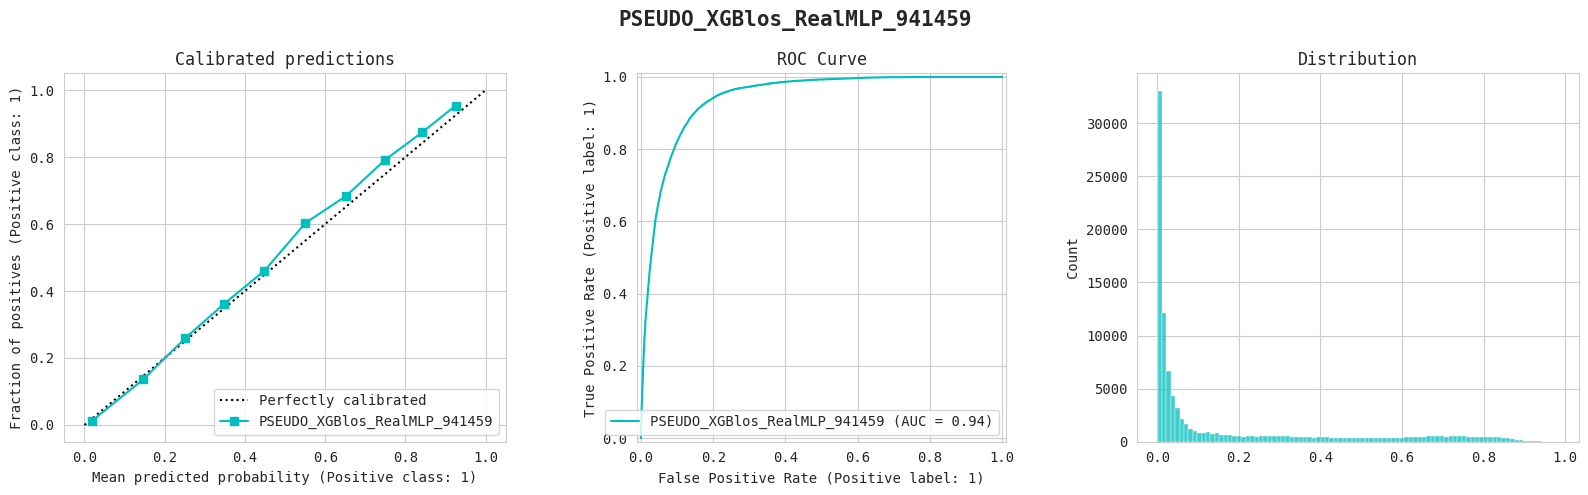

In [21]:
## -- Plot predictions errors --
name = f"PSEUDO_{m2_name}_{m1_name}_" + str(oof_auc).split('.')[1]

_, axs = plt.subplots(1, 3, figsize=(16, 5))

CalibrationDisplay.from_predictions(y_1, oof_preds, n_bins=10, name=name, ax=axs[0])
axs[0].set_title("Calibrated predictions")

RocCurveDisplay.from_predictions(y_1, oof_preds, name=name, ax=axs[1])
axs[1].set_title("ROC Curve")
# axs[1].grid(False)

sns.histplot(oof_preds, ax=axs[2])
axs[2].set_title("Distribution")

plt.suptitle(name, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

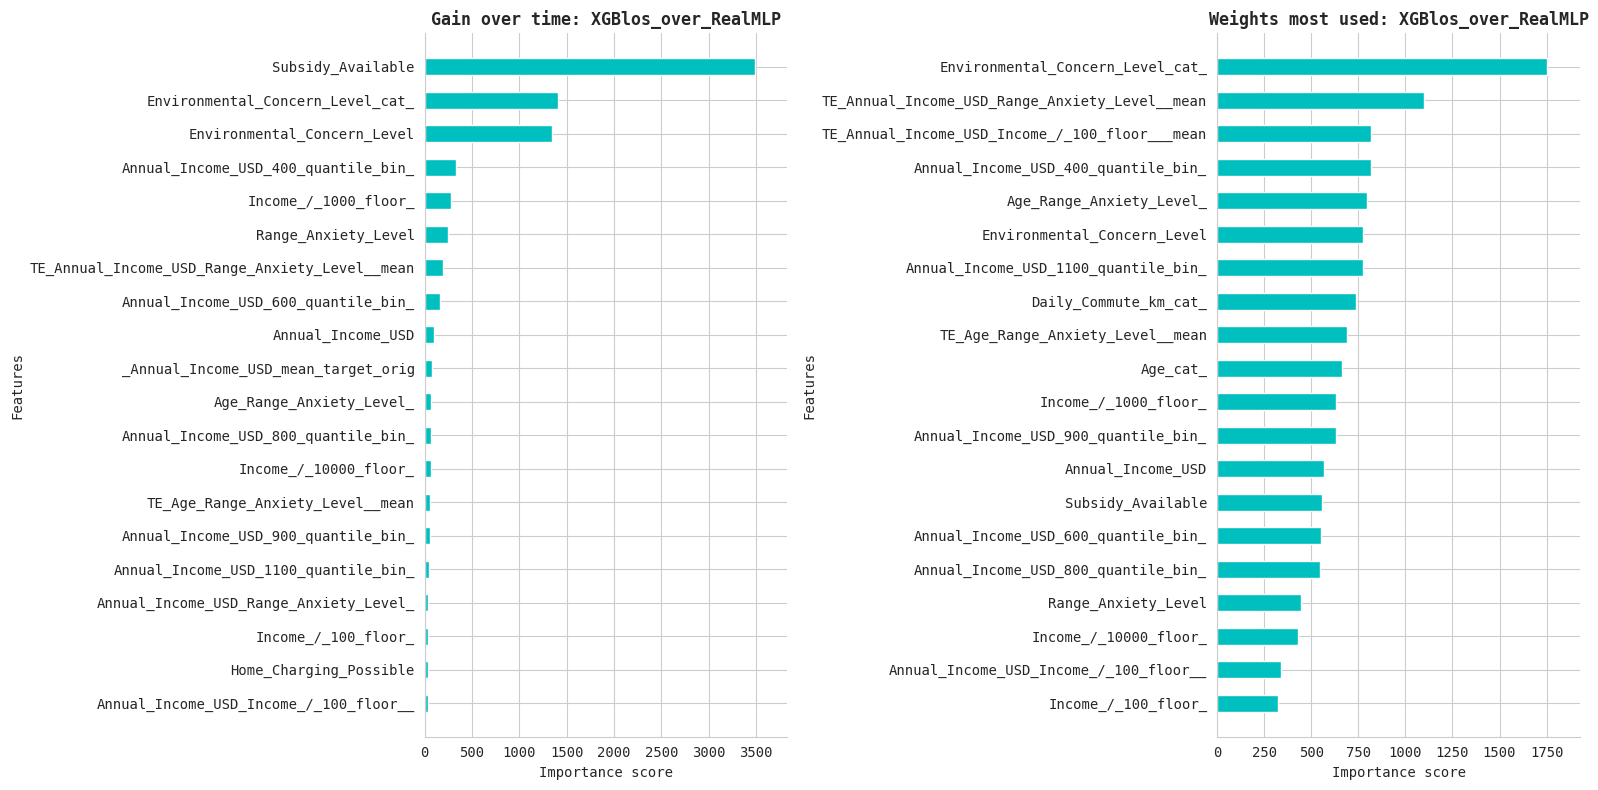

In [22]:
## -- Plot Feature Importances --
MAX = 20

_, axs = plt.subplots(1, 2, figsize=(16, 8))
xgb.plot_importance(
    model_2, ax=axs[0],
    max_num_features=MAX,
    importance_type='gain',
    height=0.5, show_values=False, #grid=False,
)
axs[0].set_title(f"Gain over time: {m2_name}_over_{m1_name}", fontdict={'weight': 'bold'})

xgb.plot_importance(
    model_2, ax=axs[1],
    max_num_features=MAX,
    importance_type='weight',
    height=0.5, show_values=False, #grid=False,
)
axs[1].set_title(f"Weights most used: {m2_name}_over_{m1_name}", fontdict={'weight': 'bold'})

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## SUBMISSION

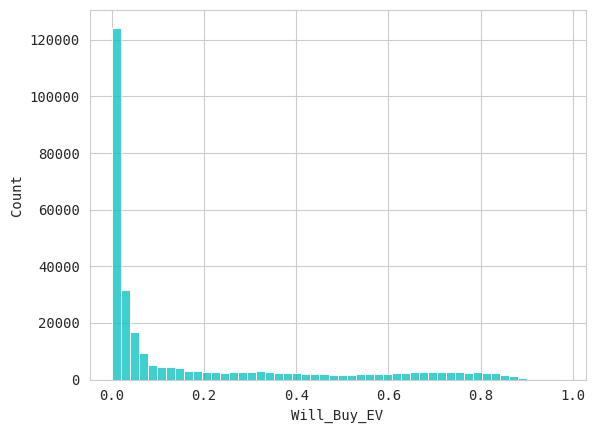

,id,Will_Buy_EV
0,668665,0.022412
1,668666,0.106335
2,668667,0.016909
3,668668,0.013843
4,668669,0.037966
...,...,...
286566,955231,0.000901
286567,955232,0.265960
286568,955233,0.009091
286569,955234,0.001214


In [23]:
## -- Save oof/test predictions --

np.save(f"oof_{name}.npy", oof_preds)
np.save(f"test_{name}.npy", test_preds)

## -- Save submission file --
submission[TARGET] = test_preds
submission.to_csv(f"submit_{name}.csv", index=False)

sns.histplot(submission[TARGET], bins=50)
plt.show()

submission

In [24]:
# !rm -r /kaggle/working